In [1]:
import os
import sys
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from tqdm import tqdm

print(jax.devices())

import importlib
try:
    importlib.reload(sys.modules["src_renyi"])
except KeyError: 
    pass
from src_renyi import (
    ARNN_Z2, RBM_Z2,
    FreeRenyiEnergyObservable,
    free_energy_minimize_SR_SGD,
    free_energy_minimize,
    free_energy_minimize_scipy,
)

[CudaDevice(id=0)]


In [13]:
# Hilbert space
from netket.hilbert import Spin
N = 20
N_ancilla = 20
partition = list(range(N))

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [14]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

Step    0 | F=-55.383367 | t=7.079s
Step   20 | F=-64.452467 | t=0.363s
Step   40 | F=-64.037136 | t=0.356s
Step   60 | F=-69.893577 | t=0.356s
Step   80 | F=-65.856015 | t=0.354s
Step  100 | F=-61.335575 | t=0.368s
Step  120 | F=-70.931555 | t=0.374s
Step  140 | F=-66.477689 | t=0.396s
Step  160 | F=-70.638590 | t=0.399s
Step  180 | F=-70.189819 | t=0.403s
Step  200 | F=-69.050936 | t=0.415s
Step  220 | F=-73.749101 | t=0.400s
Step  240 | F=-65.682916 | t=0.393s
Step  260 | F=-73.066784 | t=0.427s
Step  280 | F=-76.818971 | t=0.461s


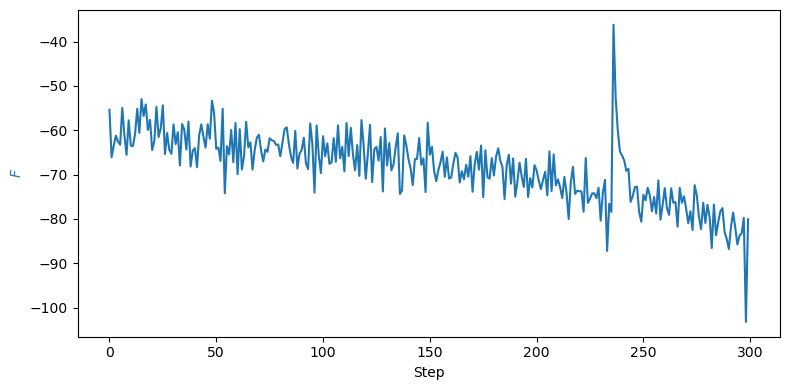

Best solution: S₂=8.128271, E=-3.749746, F=-85.032452


In [15]:
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
T = 10

n_steps = 300
lr = optax.linear_schedule(0.05, 0.001, n_steps)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)
_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr,
                                                      diag_shift=diag_shift, freq=20, timing=True, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

In [ ]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
optimizer = optax.sign_sgd(lr)
# optimizer = optax.adam(lr)
T = 20
_,f_best,E_best,S_best = free_energy_minimize(vstate, T, partition, H_extended, 500, freq=20,
                                               optimizer=optimizer, learning_rate=lr, clip_norm=0.05, timing=True)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

Temperaturas:   0%|          | 0/41 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | F=-74.256933
Step   50 | F=-83.588859
Step  100 | F=-83.586771
Step  150 | F=-83.581756
Step  200 | F=-83.582629
Step  250 | F=-83.587543


Temperaturas:   2%|▏         | 1/41 [07:17<4:51:33, 437.34s/it]

  Mejor resultado: E=-83.5892, S₂=0.0030, F=-83.5892

=== Temperatura T = 0.100 ===
Step    0 | F=-83.588877
Step   50 | F=-83.579661
Step  100 | F=-83.582707
Step  150 | F=-83.582208
Step  200 | F=-83.580715
Step  250 | F=-83.578821


Temperaturas:   5%|▍         | 2/41 [14:34<4:44:20, 437.45s/it]

...

  Mejor resultado: E=-38.5333, S₂=7.6246, F=-67.5068

=== Temperatura T = 3.900 ===
Step    0 | F=-68.248262
Step   50 | F=-62.471670
Step  100 | F=-65.335768
Step  150 | F=-65.141630
Step  200 | F=-65.795465
Step  250 | F=-65.032397


Temperaturas:  98%|█████████▊| 40/41 [5:07:41<07:05, 425.13s/it]

  Mejor resultado: E=-39.3276, S₂=7.3623, F=-68.0404

=== Temperatura T = 4.000 ===
Step    0 | F=-66.685750
Step   50 | F=-61.545627
Step  100 | F=-65.543976
Step  150 | F=-63.212517
Step  200 | F=-67.974421
Step  250 | F=-73.901678


Temperaturas: 100%|██████████| 41/41 [5:15:09<00:00, 461.20s/it]

  Mejor resultado: E=-38.4917, S₂=7.6246, F=-68.9902


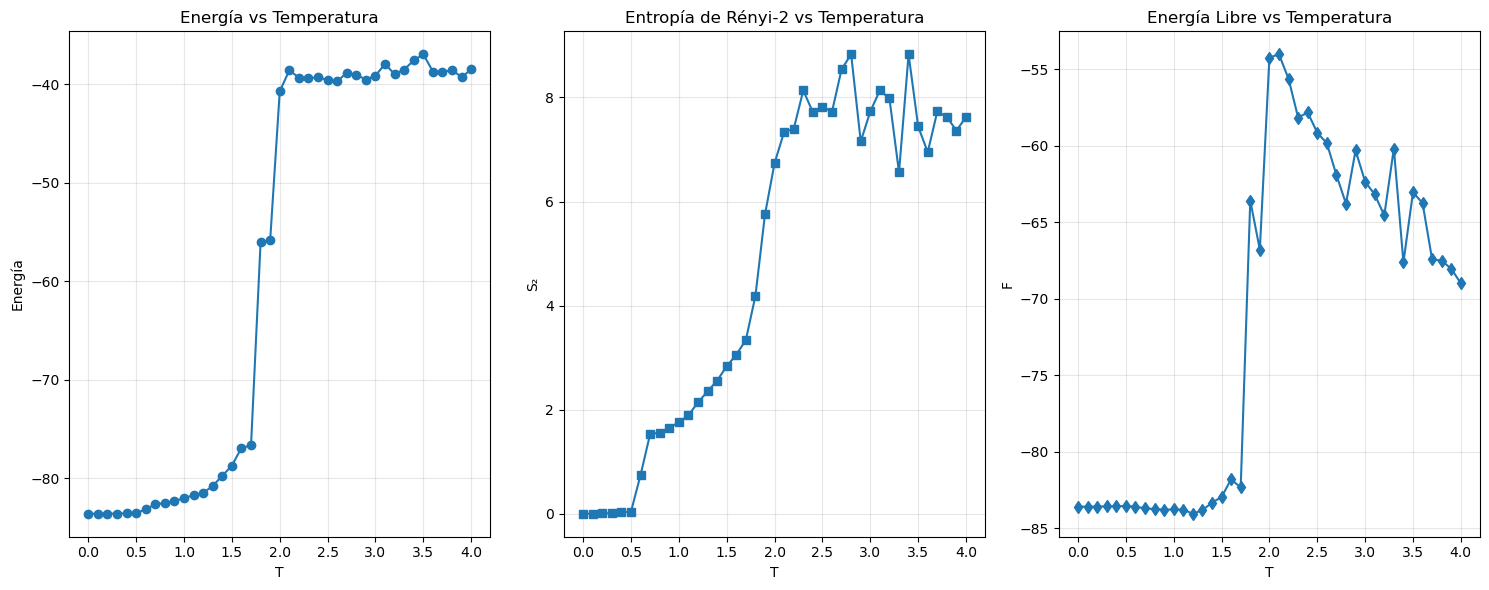

In [6]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960/2, chunk_size=None)

T_array = np.linspace(0, 4, 41)
n_steps = 300

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None
os.makedirs(f"../data/N{N}/params", exist_ok=True)

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    if best_params is not None:
        vstate.parameters = best_params

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate = optax.linear_schedule(0.05, 0.001, n_steps),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
        n_samples_sr=4096
    )
    best_params = vstate.parameters
    filename = f"../data/N{N}/params/params_T_{T:.3f}.msgpack"

    with open(filename, "wb") as f:
        f.write(serialization.to_bytes(best_params))

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

os.makedirs(f"../data/N{N}", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"../data/N{N}/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()